# Diagnose a shortcut, then verify a training repair

[Open in Colab](https://colab.research.google.com/github/frgfm/notebooks/blob/main/torch-cam/shortcut_repair.ipynb)

Train a tiny CNN to distinguish a **vertical from a horizontal gray bar**. A colored corner patch is correlated
with the training label but independent of the label on the final test set. GradCAM proposes a region to
investigate; label-preserving interventions and matched controls test that proposal. Then compare continued
unchanged training, ordinary random erasing, and CAM-guided erasing, with a stricter gated arm as an additional
control. Repeat the complete workflow without
the training correlation as a negative control.

This extends the evidence-first [validation audit](validation_audit.ipynb): fixed discovery probes include
successes and failures, and blank maps, extraction errors, rejected hypotheses, and unsuccessful repairs
remain in the record. It uses native PyTorch and the **merged** TorchCAM APIs, with no dataset or weight downloads.
All coordinates refer to the exact 32×32 model input; there is no resize, crop, normalization, or display mismatch.


## Tested environment and execution

Tested on Linux, Python 3.11.16, CPU, two PyTorch threads. The `+cpu` wheel pins target Linux/Colab.
Run **all cells in order**, including setup, in a fresh Python 3.11 kernel.
Setup installs only missing/mismatched pins and validates TorchCAM's installed VCS revision;
if imported packages need changing, restart first. The TorchCAM pin is merged main `5a0bc4d`
(including the CAM/metric corrections), not the validation audit's unmerged evidence-context API.

Headless execution after installing the same pins, using only the pinned notebook dependencies:

```python
import nbformat
from nbclient import NotebookClient
path = "torch-cam/shortcut_repair.ipynb"
nb = nbformat.read(path, as_version=4)
NotebookClient(nb, timeout=1800, kernel_name="python3").execute()
nbformat.write(nb, path)
```
The last cells are runnable acceptance checks, not an assertion that repair must improve accuracy.


In [1]:
import json
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, distribution, version

SOURCE_REVISION = "5a0bc4d439ad642a37ed301d94601048e8d32de8"
PINS = {
    "torch": "2.14.1+cpu",
    "torchvision": "0.29.1+cpu",
    "numpy": "2.4.6",
    "matplotlib": "3.11.2",
    "Pillow": "12.3.0",
    "nbformat": "5.10.4",
    "nbclient": "0.10.2",
    "ipykernel": "6.30.1",
}


def installed_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return None


def source_commit():
    try:
        direct_url = json.loads(distribution("torchcam").read_text("direct_url.json") or "{}")
        return direct_url.get("vcs_info", {}).get("commit_id")
    except PackageNotFoundError:
        return None


needs_setup = any(installed_version(p) != v for p, v in PINS.items()) or source_commit() != SOURCE_REVISION
if needs_setup:
    if any(p in sys.modules for p in ("torch", "torchvision", "torchcam", "numpy", "matplotlib", "PIL")):
        raise RuntimeError("Restart the kernel before changing loaded dependencies, then run all cells.")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--index-url",
        "https://download.pytorch.org/whl/cpu",
        "torch==2.14.1+cpu",
        "torchvision==0.29.1+cpu",
    ])
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *[f"{p}=={v}" for p, v in PINS.items() if p not in ("torch", "torchvision")],
    ])
    requirement = f"torchcam @ git+https://github.com/frgfm/torch-cam.git@{SOURCE_REVISION}"
    # Development commits can share the same version; force replacement, without changing pinned dependencies.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-deps", "--force-reinstall", requirement])
assert source_commit() == SOURCE_REVISION
assert all(installed_version(p) == v for p, v in PINS.items())
print("PASS: tested dependencies and merged TorchCAM revision.")

PASS: tested dependencies and merged TorchCAM revision.


## Protocol fixed before any test evaluation

| Item | Fixed choice |
|---|---|
| Seeds | 7, 17, 27; paired data, initialization, batch order, and edit decisions across arms |
| Training / discovery / confirmation / test | 1,024 / 64 / 256 / 1,024 unique generated images per seed and regime |
| Training cue agreement | 95% target, rounded to 94.92% (shortcut); 50% (no-shortcut control), balanced classes |
| Discovery, confirmation, final test | Cue independent of label; exact balance over label × cue, no shared images |
| Model / optimizer | Input centered at 0.5; 3 convolution layers, global average pool, linear head; Adam, learning rate 0.003 |
| Training budget | Shared 4-epoch pilot; clone its checkpoint for 32 continuation epochs per arm; batch 64 |
| CAM target / proposals | Predicted raw class logit, `features`; aggregate normalized map mass over 8 equal border tiles |
| Confirmation | Top 3 CAM-ranked tiles; neutralization and independent training-donor blend, each with 7 matched-location controls |
| Selection gate | Both edit types: mean predicted-class probability drop minus mean control drop > 0.02, descriptive paired bootstrap lower bound > 0 |
| Guided versus gated | Guided tries the first supported tile, otherwise the top CAM proposal provisionally; gated acts only on a supported tile |
| Repair / ordinary augmentation | Erase 1 border tile on the same 75% of presentations, fill 0.5; guided uses the first supported CAM-ranked tile, ordinary chooses uniformly |
| Final evaluation | Once all arms/seeds/regimes are frozen: original independent-cue test images, overall and minimum of 4 label × cue groups |

The diagnostic workflow receives **images and class labels only**, plus the task contract that the label is
the central bar's orientation and that the outer 8-pixel border can be changed without changing that label.
It does not receive cue location, color IDs, agreement flags, or group IDs. The generator's oracle records
live in a separate structure, accessed only for acceptance checks and final group scoring. This is a controlled,
task-informed diagnosis, not automatic discovery of arbitrary label-preserving edits.

The independent-cue validation distribution is a deliberately supplied stress set. It is not selected from
test results. The shortlist and thresholds are fixed here; intervals over 256 confirmation images are descriptive
and uncorrected for testing three regions. If no proposal passes, the diagnosis stays unresolved. Guided
erasing still **tests the top provisional CAM proposal**; gated erasing falls back to unchanged training.
If no finite nonblank CAM is available, both fall back. Provisional repairs must earn their result in the
untouched test comparison; they do not convert an unresolved diagnosis into a causal claim.
No hyperparameter, seed, or checkpoint is selected on final test accuracy.

Discovery, confirmation, and test images are paired across the two regimes. They are disjoint from training and from each other within each seed. The regimes are not six independent test datasets.


In [2]:
%matplotlib inline
import copy
import hashlib
import math
import platform
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from torch import nn
from torch.nn import functional as F
from torchcam.explain import explain

torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
DEVICE = "cpu"
SEEDS = (7, 17, 27)
REGIMES = ("shortcut", "no_shortcut")
ARMS = ("unchanged", "ordinary", "guided", "gated")
BATCH, PILOT_EPOCHS, REPAIR_EPOCHS = 64, 4, 32
CENTRAL_NOISE, BAR_CONTRAST = 0.035, (0.25, 0.40)
INPUT_CENTER, TEST_SEED_OFFSET = 0.5, 100000
EDIT_PROBABILITY = 0.75
# These tiles enumerate the entire task-permitted rim; no oracle cue coordinates are consulted.
TILES = [(y, x) for y in (0, 8, 16, 24) for x in (0, 8, 16, 24) if y in (0, 24) or x in (0, 24)]
# Use 8 disjoint, symmetrically positioned tiles, avoiding middle edge locations.
TILES = [TILES[i] for i in (0, 1, 2, 3, 8, 9, 10, 11)]
runtime = {
    "python": platform.python_version(),
    "device": DEVICE,
    "threads": torch.get_num_threads(),
    "torchcam_commit": source_commit(),
    "torchcam": version("torchcam"),
    **PINS,
}
artifact_dir = Path(tempfile.mkdtemp(prefix="torchcam-shortcut-"))
print(json.dumps(runtime, indent=2))

{
  "python": "3.11.16",
  "device": "cpu",
  "threads": 2,
  "torchcam_commit": "5a0bc4d439ad642a37ed301d94601048e8d32de8",
  "torchcam": "0.6.0.dev0",
  "torch": "2.14.1+cpu",
  "torchvision": "0.29.1+cpu",
  "numpy": "2.4.6",
  "matplotlib": "3.11.2",
  "Pillow": "12.3.0",
  "nbformat": "5.10.4",
  "nbclient": "0.10.2",
  "ipykernel": "6.30.1"
}


## Preserve the unsuccessful first attempt

This is a developed experiment, not a preregistered study. An initial executed protocol used weaker bars
(contrast 0.10–0.26, central noise SD 0.055), uncentered inputs, and 4 + 12 epochs. All three arms scored
50% average and 0% worst-group accuracy in both regimes. CAM ranked the injected corner first in all shortcut
seeds, but the confirmation gate rejected every repair. The no-shortcut classifier was also at chance on
**validation**, so task learning had not been established. The initial test results had already been viewed.

The final protocol above was refined using **training/validation evidence**: brighter bars, input centering,
32 continuation epochs, and separate provisional/gated arms. Validation-only pilots established task learning
in the no-shortcut regime (100% at continuation end for all seeds). The final test uses new generation seeds
(offset 100,000 rather than 3,000) and was unopened until the revised protocol and all models were frozen.
Initial test images are never reused for final measurement. No selection is based on the initial or final test
scores. The archival record below keeps the initial protocol, all seed-level outcomes/losses, rejected edits,
and unresolved diagnoses; final claims refer only to the fresh test comparison.

To reconstruct the first attempt, set the generator noise/contrast and input centering to the values above,
use 12 continuation epochs and test seed offset 3,000, and run the current gated policy as initial guided.
The initial frozen results are included in the exported report even on a fresh runtime.


In [3]:
INITIAL_ATTEMPT = json.loads(r"""
{"configuration":{"notebook_base":"frgfm/notebooks@493d93b0be06eee98264609e6c025dc798e65ad2","seeds":[7,17,27],"regimes":["shortcut","no_shortcut"],"arms":["unchanged","ordinary","guided"],"splits":{"train":1024,"discovery":64,"confirmation":256,"test":1024},"pilot_epochs":4,"continuation_epochs":12,"batch_size":64,"optimizer":"Adam(lr=0.003), reset at continuation for all arms","tiles_yx":[[0,0],[0,8],[0,16],[0,24],[24,0],[24,8],[24,16],[24,24]],"target_layer":"features","cam":"GradCAM; original predicted raw logit; 8x8 -> 32x32 bilinear","selection":"top-3 CAM rank; both edits excess drop > 0.02 and paired bootstrap lower bound > 0","bootstrap":"1000 image resamples; seed + 5000; descriptive, no multiplicity correction","edit_probability":0.75,"repair":"8x8 border erasure, neutral 0.5","available_to_workflow":["train/discovery/confirmation images","class labels","protected central task region"],"oracle_usage":"generator, acceptance checks, and final group scoring only","test_policy":"one evaluation after all training frozen; no feedback into selection","augmentation_pairing":"seed + 6000; same batch permutation and Bernoulli decisions each epoch","donor_source":"training only; seed + 4000, sampled without label conditioning","diagnostic_compute_extra":"64 explanations (predicted + expected), 48 edited confirmation passes of 256 images per resolved shortlist","central_noise_sd":0.055,"bar_contrast_range":[0.1,0.26],"input_centering":0,"split_seed_offsets":{"train":0,"discovery":1000,"confirmation":2000,"test":3000},"guided_policy":"strictly gated; unresolved => unchanged (the current gated arm)"},"runtime":{"python":"3.11.16","device":"cpu","threads":2,"torchcam_commit":"5a0bc4d439ad642a37ed301d94601048e8d32de8","torchcam":"0.6.0.dev0","torch":"2.14.1+cpu","torchvision":"0.29.1+cpu","numpy":"2.4.6","matplotlib":"3.11.2","Pillow":"12.3.0","nbformat":"5.10.4","nbclient":"0.10.2","ipykernel":"6.30.1"},"summary":[{"regime":"shortcut","arm":"unchanged","accuracy_mean":0.5,"accuracy_sd":0.0,"worst_group_mean":0.0,"worst_group_sd":0.0},{"regime":"shortcut","arm":"ordinary","accuracy_mean":0.5,"accuracy_sd":0.0,"worst_group_mean":0.0,"worst_group_sd":0.0},{"regime":"shortcut","arm":"guided","accuracy_mean":0.5,"accuracy_sd":0.0,"worst_group_mean":0.0,"worst_group_sd":0.0},{"regime":"no_shortcut","arm":"unchanged","accuracy_mean":0.5,"accuracy_sd":0.0,"worst_group_mean":0.0,"worst_group_sd":0.0},{"regime":"no_shortcut","arm":"ordinary","accuracy_mean":0.5,"accuracy_sd":0.0,"worst_group_mean":0.0,"worst_group_sd":0.0},{"regime":"no_shortcut","arm":"guided","accuracy_mean":0.5,"accuracy_sd":0.0,"worst_group_mean":0.0,"worst_group_sd":0.0}],"split_hashes":{"shortcut/7/train":"1bf1865c2793a189d22e1b3440a7c82888f9e0b1c4c477be1e1e5930caf8db1a","shortcut/7/discovery":"86c26d3b3b83f3353a989e87832bd28b11cbcf1d45ef628e5fe54fa3f8b75757","shortcut/7/confirmation":"cb674709ec574290212c99a047228538387351e97ca5f8b9fad2897c45a936f7","shortcut/7/test":"3c2ed7337a52f3af9940f0196c0890b191ba334cf24daa3cf6d308dee922acf1","shortcut/17/train":"995a5f82216f92baebb5a1aad53125abe46aecd488974da187a87bac02f16bf7","shortcut/17/discovery":"85049a9e9a894da9a9b9c6d0f2e010127e89a1f6e410078c1612575ce229b7c0","shortcut/17/confirmation":"6a46a93dcf366a4ffb32ef9fdc35ebac8dafdef4cd7b8d0cc7755c3e24a981fd","shortcut/17/test":"e6d92ba1500166389bcbd1610dbd5d8062595d1a7eef25bf6617aa2620d283a3","shortcut/27/train":"ff5f3c4bf871142e961e4be6115feb8be1c8b70e90a878da01d69d506c8a64a0","shortcut/27/discovery":"61a8e93aa68ce245491201c170df70fa5872c3eda797a94cdc3679db03758cac","shortcut/27/confirmation":"f4c06a32724a0a502bd54d0ab7db3516d8718856f32a8b0646e98d94f54039a2","shortcut/27/test":"b88a0c02e5f0cbcf694d0b89177d0bf2750dd2af69eb3166b0c8b7253a2ea16e","no_shortcut/7/train":"d06c1c1c75c8627a78c3cab047cf94497a58af3816d759836d26450a393355b0","no_shortcut/7/discovery":"86c26d3b3b83f3353a989e87832bd28b11cbcf1d45ef628e5fe54fa3f8b75757","no_shortcut/7/confirmation":"cb674709ec574290212c99a047228538387351e97ca5f8b9fad2897c45a936f7","no_shortcut/7/test":"3c2ed7337a52f3af9940f0196c0890b191ba334cf24daa3cf6d308dee922acf1","no_shortcut/17/train":"b1b44ac6a15f998ee733f584fc9731b816d1eb6a9a3ed55d5df3625168afce81","no_shortcut/17/discovery":"85049a9e9a894da9a9b9c6d0f2e010127e89a1f6e410078c1612575ce229b7c0","no_shortcut/17/confirmation":"6a46a93dcf366a4ffb32ef9fdc35ebac8dafdef4cd7b8d0cc7755c3e24a981fd","no_shortcut/17/test":"e6d92ba1500166389bcbd1610dbd5d8062595d1a7eef25bf6617aa2620d283a3","no_shortcut/27/train":"d01c359c72cf41b157c7d0884e586a063c2a4a40b6223a90d9749bb2c46f680e","no_shortcut/27/discovery":"61a8e93aa68ce245491201c170df70fa5872c3eda797a94cdc3679db03758cac","no_shortcut/27/confirmation":"f4c06a32724a0a502bd54d0ab7db3516d8718856f32a8b0646e98d94f54039a2","no_shortcut/27/test":"b88a0c02e5f0cbcf694d0b89177d0bf2750dd2af69eb3166b0c8b7253a2ea16e"},"seed_results":[{"regime":"shortcut","seed":7,"arm":"unchanged","pilot_losses":[0.6915136240422726,0.6694035343825817,0.5633318983018398,0.3875342831015587],"losses":[0.3253939161077142,0.23945992067456245,0.20930462190881371,0.20333865517750382,0.20548164402134717,0.20557981403544545,0.20394938834942877,0.2018904904834926,0.2058209558017552,0.20278174430131912,0.20179818803444505,0.20205927779898047],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"shortcut","seed":7,"arm":"ordinary","pilot_losses":[0.6915136240422726,0.6694035343825817,0.5633318983018398,0.3875342831015587],"losses":[0.44611562695354223,0.33123570028692484,0.31891531217843294,0.2936099683865905,0.31290180794894695,0.2742166155949235,0.28402655851095915,0.2966685090214014,0.27296495204791427,0.28430727031081915,0.29261674359440804,0.2947218967601657],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"shortcut","seed":7,"arm":"guided","pilot_losses":[0.6915136240422726,0.6694035343825817,0.5633318983018398,0.3875342831015587],"losses":[0.3253939161077142,0.23945992067456245,0.20930462190881371,0.20333865517750382,0.20548164402134717,0.20557981403544545,0.20394938834942877,0.2018904904834926,0.2058209558017552,0.20278174430131912,0.20179818803444505,0.20205927779898047],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"shortcut","seed":17,"arm":"unchanged","pilot_losses":[0.6944624148309231,0.6887742504477501,0.6764276660978794,0.631787184625864],"losses":[0.5991101898252964,0.5229376368224621,0.4275845419615507,0.34619557671248913,0.3081265389919281,0.2781060179695487,0.2551890732720494,0.28667056653648615,0.2159628663212061,0.22102986788377166,0.20813067862764,0.20510565815493464],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"shortcut","seed":17,"arm":"ordinary","pilot_losses":[0.6944624148309231,0.6887742504477501,0.6764276660978794,0.631787184625864],"losses":[0.6191790737211704,0.562249518930912,0.49836835265159607,0.39729011431336403,0.35489192325621843,0.32323136180639267,0.2932543605566025,0.3540137829259038,0.3256225595250726,0.302781599573791,0.25749024376273155,0.2656540088355541],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"shortcut","seed":17,"arm":"guided","pilot_losses":[0.6944624148309231,0.6887742504477501,0.6764276660978794,0.631787184625864],"losses":[0.5991101898252964,0.5229376368224621,0.4275845419615507,0.34619557671248913,0.3081265389919281,0.2781060179695487,0.2551890732720494,0.28667056653648615,0.2159628663212061,0.22102986788377166,0.20813067862764,0.20510565815493464],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"shortcut","seed":27,"arm":"unchanged","pilot_losses":[0.6961564272642136,0.6835750415921211,0.6394981443881989,0.5603738334029913],"losses":[0.4555200822651386,0.36646705493330956,0.2798554375767708,0.2248256327584386,0.21278846822679043,0.2119757323525846,0.2081434028223157,0.2190741579979658,0.23218436818569899,0.20987184764817357,0.22785058757290244,0.20582519518211484],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"shortcut","seed":27,"arm":"ordinary","pilot_losses":[0.6961564272642136,0.6835750415921211,0.6394981443881989,0.5603738334029913],"losses":[0.51703099347651,0.4101619105786085,0.35781663097441196,0.32820173911750317,0.29090277571231127,0.2660168595612049,0.2659692969173193,0.25488349702209234,0.28025951609015465,0.2843157141469419,0.26111193653196096,0.27192797884345055],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"shortcut","seed":27,"arm":"guided","pilot_losses":[0.6961564272642136,0.6835750415921211,0.6394981443881989,0.5603738334029913],"losses":[0.4555200822651386,0.36646705493330956,0.2798554375767708,0.2248256327584386,0.21278846822679043,0.2119757323525846,0.2081434028223157,0.2190741579979658,0.23218436818569899,0.20987184764817357,0.22785058757290244,0.20582519518211484],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"no_shortcut","seed":7,"arm":"unchanged","pilot_losses":[0.6943412981927395,0.6932435035705566,0.6932108961045742,0.6932548731565475],"losses":[0.6936959885060787,0.6933471374213696,0.6932560205459595,0.6931817792356014,0.6932888105511665,0.6931591033935547,0.6932837851345539,0.6933445185422897,0.6933389641344547,0.6932442300021648,0.6934181861579418,0.6931721642613411],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"no_shortcut","seed":7,"arm":"ordinary","pilot_losses":[0.6943412981927395,0.6932435035705566,0.6932108961045742,0.6932548731565475],"losses":[0.6936927251517773,0.6933616995811462,0.6932650581002235,0.6931834854185581,0.6932949237525463,0.6931606978178024,0.6932903714478016,0.6933625526726246,0.6933556832373142,0.6932342983782291,0.6934216991066933,0.6931694224476814],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"no_shortcut","seed":7,"arm":"guided","pilot_losses":[0.6943412981927395,0.6932435035705566,0.6932108961045742,0.6932548731565475],"losses":[0.6936959885060787,0.6933471374213696,0.6932560205459595,0.6931817792356014,0.6932888105511665,0.6931591033935547,0.6932837851345539,0.6933445185422897,0.6933389641344547,0.6932442300021648,0.6934181861579418,0.6931721642613411],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"no_shortcut","seed":17,"arm":"unchanged","pilot_losses":[0.6946942061185837,0.6933277808129787,0.6949817314743996,0.69357630610466],"losses":[0.6940387785434723,0.6937017254531384,0.694135744124651,0.693281888961792,0.6933694407343864,0.6945050209760666,0.6953294798731804,0.6937218718230724,0.6934575736522675,0.6933694072067738,0.6933736428618431,0.6935082003474236],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"no_shortcut","seed":17,"arm":"ordinary","pilot_losses":[0.6946942061185837,0.6933277808129787,0.6949817314743996,0.69357630610466],"losses":[0.6940422803163528,0.6937009878456593,0.6941329054534435,0.6932831518352032,0.6933737397193909,0.6945086307823658,0.6947335228323936,0.693601444363594,0.6933809109032154,0.6933414600789547,0.6933842040598392,0.6935169920325279],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"no_shortcut","seed":17,"arm":"guided","pilot_losses":[0.6946942061185837,0.6933277808129787,0.6949817314743996,0.69357630610466],"losses":[0.6940387785434723,0.6937017254531384,0.694135744124651,0.693281888961792,0.6933694407343864,0.6945050209760666,0.6953294798731804,0.6937218718230724,0.6934575736522675,0.6933694072067738,0.6933736428618431,0.6935082003474236],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"no_shortcut","seed":27,"arm":"unchanged","pilot_losses":[0.6980459466576576,0.6949687227606773,0.6941084414720535,0.6938152872025967],"losses":[0.6960505396127701,0.6939165703952312,0.6934569664299488,0.693960040807724,0.6941471323370934,0.6931094266474247,0.6942257918417454,0.6937900185585022,0.6941467002034187,0.6935274079442024,0.6936633922159672,0.6938782893121243],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"no_shortcut","seed":27,"arm":"ordinary","pilot_losses":[0.6980459466576576,0.6949687227606773,0.6941084414720535,0.6938152872025967],"losses":[0.6960501112043858,0.6939137503504753,0.6934586018323898,0.6939669214189053,0.6941431686282158,0.6931069977581501,0.6942233815789223,0.6937929950654507,0.6941469497978687,0.6935253068804741,0.6936623156070709,0.6938785165548325],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}},{"regime":"no_shortcut","seed":27,"arm":"guided","pilot_losses":[0.6980459466576576,0.6949687227606773,0.6941084414720535,0.6938152872025967],"losses":[0.6960505396127701,0.6939165703952312,0.6934569664299488,0.693960040807724,0.6941471323370934,0.6931094266474247,0.6942257918417454,0.6937900185585022,0.6941467002034187,0.6935274079442024,0.6936633922159672,0.6938782893121243],"test":{"n":1024,"accuracy":0.5,"worst_group":0.0,"groups":[{"label":0,"cue":0,"n":256,"correct":0,"accuracy":0.0},{"label":0,"cue":1,"n":256,"correct":0,"accuracy":0.0},{"label":1,"cue":0,"n":256,"correct":256,"accuracy":1.0},{"label":1,"cue":1,"n":256,"correct":256,"accuracy":1.0}]}}],"diagnoses":[{"regime":"shortcut","seed":7,"diagnosis":{"status":"unresolved","chosen_tile":null,"cam_scores":[0.31244301376864314,0.13118348619900644,0.026138274399272632,0.02565869865793502,0.023956432531122118,0.030892744079478174,0.03133306753409215,0.030412375444386797],"shortlist":[0,1,6],"probes":[{"sample":0,"expected":1,"status":"ok","predicted":0,"correct":false,"bundle":"shortcut-7-example"},{"sample":1,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":2,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":3,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":4,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":5,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":6,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":7,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":8,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":9,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":10,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":11,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":12,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":13,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":14,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":15,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":16,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":17,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":18,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":19,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":20,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":21,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":22,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":23,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":24,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":25,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":26,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":27,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":28,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":29,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":30,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":31,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":32,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":33,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":34,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":35,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":36,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":37,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":38,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":39,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":40,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":41,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":42,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":43,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":44,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":45,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":46,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":47,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":48,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":49,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":50,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":51,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":52,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":53,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":54,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":55,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":56,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":57,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":58,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":59,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":60,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":61,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":62,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":63,"expected":0,"status":"ok","predicted":0,"correct":true}],"interventions":[{"tile":0,"box_yx":[0,0],"edit":"neutralize","predicted_probability_drop":0.31843331456184387,"control_probability_drop":0.2672552466392517,"paired_excess_drop":0.051178086549043655,"bootstrap_95":[-0.0010707063367590309,0.10339146219193936],"label_probability_drop":-7.268041372299194e-06,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.5,"control_flip_rate":0.5,"supported":false},{"tile":0,"box_yx":[0,0],"edit":"donor_blend","predicted_probability_drop":0.15908099710941315,"control_probability_drop":0.13357451558113098,"paired_excess_drop":0.025506483390927315,"bootstrap_95":[-0.01363270424772054,0.06464940179139375],"label_probability_drop":0.013786246068775654,"target_accuracy":0.4765625,"original_accuracy":0.5,"target_flip_rate":0.25,"control_flip_rate":0.25,"supported":false},{"tile":1,"box_yx":[0,8],"edit":"neutralize","predicted_probability_drop":0.0,"control_probability_drop":6.984919309616089e-10,"paired_excess_drop":-6.984919309616089e-10,"bootstrap_95":[-7.2177499532699585e-09,6.05359673500061e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":1,"box_yx":[0,8],"edit":"donor_blend","predicted_probability_drop":0.0,"control_probability_drop":6.984919309616089e-10,"paired_excess_drop":-6.984919309616089e-10,"bootstrap_95":[-7.2177499532699585e-09,6.05359673500061e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":6,"box_yx":[24,16],"edit":"neutralize","predicted_probability_drop":0.0,"control_probability_drop":6.984919309616089e-10,"paired_excess_drop":-6.984919309616089e-10,"bootstrap_95":[-7.2177499532699585e-09,6.05359673500061e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":6,"box_yx":[24,16],"edit":"donor_blend","predicted_probability_drop":0.0,"control_probability_drop":6.984919309616089e-10,"paired_excess_drop":-6.984919309616089e-10,"bootstrap_95":[-7.2177499532699585e-09,6.05359673500061e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false}]}},{"regime":"shortcut","seed":17,"diagnosis":{"status":"unresolved","chosen_tile":null,"cam_scores":[0.22236650506965816,0.1110723870806396,0.03446454615914263,0.0322854733094573,0.03454196866368875,0.04078626717091538,0.040583798952866346,0.03757048424449749],"shortlist":[0,1,5],"probes":[{"sample":0,"expected":1,"status":"ok","predicted":0,"correct":false,"bundle":"shortcut-17-example"},{"sample":1,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":2,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":3,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":4,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":5,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":6,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":7,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":8,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":9,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":10,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":11,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":12,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":13,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":14,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":15,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":16,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":17,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":18,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":19,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":20,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":21,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":22,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":23,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":24,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":25,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":26,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":27,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":28,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":29,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":30,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":31,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":32,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":33,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":34,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":35,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":36,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":37,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":38,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":39,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":40,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":41,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":42,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":43,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":44,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":45,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":46,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":47,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":48,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":49,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":50,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":51,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":52,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":53,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":54,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":55,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":56,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":57,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":58,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":59,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":60,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":61,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":62,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":63,"expected":1,"status":"ok","predicted":0,"correct":false}],"interventions":[{"tile":0,"box_yx":[0,0],"edit":"neutralize","predicted_probability_drop":0.07192666083574295,"control_probability_drop":0.057699739933013916,"paired_excess_drop":0.014226917177438736,"bootstrap_95":[0.010835798247717321,0.017624031007289886],"label_probability_drop":-1.0965974070131779e-05,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.5,"control_flip_rate":0.5,"supported":false},{"tile":0,"box_yx":[0,0],"edit":"donor_blend","predicted_probability_drop":0.03708852827548981,"control_probability_drop":0.02974640391767025,"paired_excess_drop":0.007342120632529259,"bootstrap_95":[0.004799744160845876,0.01005482361651957],"label_probability_drop":0.001815399737097323,"target_accuracy":0.46875,"original_accuracy":0.5,"target_flip_rate":0.2578125,"control_flip_rate":0.2578125,"supported":false},{"tile":1,"box_yx":[0,8],"edit":"neutralize","predicted_probability_drop":0.0,"control_probability_drop":-3.026798367500305e-09,"paired_excess_drop":3.026798367500305e-09,"bootstrap_95":[-9.37143340706825e-10,6.752088665962219e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":1,"box_yx":[0,8],"edit":"donor_blend","predicted_probability_drop":0.0,"control_probability_drop":-3.026798367500305e-09,"paired_excess_drop":3.026798367500305e-09,"bootstrap_95":[-9.37143340706825e-10,6.752088665962219e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":5,"box_yx":[24,8],"edit":"neutralize","predicted_probability_drop":0.0,"control_probability_drop":-3.026798367500305e-09,"paired_excess_drop":3.026798367500305e-09,"bootstrap_95":[-9.37143340706825e-10,6.752088665962219e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":5,"box_yx":[24,8],"edit":"donor_blend","predicted_probability_drop":0.0,"control_probability_drop":-3.026798367500305e-09,"paired_excess_drop":3.026798367500305e-09,"bootstrap_95":[-9.37143340706825e-10,6.752088665962219e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false}]}},{"regime":"shortcut","seed":27,"diagnosis":{"status":"unresolved","chosen_tile":null,"cam_scores":[0.40038725128397346,0.15801155765075237,0.021646956854965538,0.02140216314001009,0.010157040919693827,0.018648148339707404,0.018794610863551497,0.018664465751498938],"shortlist":[0,1,2],"probes":[{"sample":0,"expected":1,"status":"ok","predicted":1,"correct":true,"bundle":"shortcut-27-example"},{"sample":1,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":2,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":3,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":4,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":5,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":6,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":7,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":8,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":9,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":10,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":11,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":12,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":13,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":14,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":15,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":16,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":17,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":18,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":19,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":20,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":21,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":22,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":23,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":24,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":25,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":26,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":27,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":28,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":29,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":30,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":31,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":32,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":33,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":34,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":35,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":36,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":37,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":38,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":39,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":40,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":41,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":42,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":43,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":44,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":45,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":46,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":47,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":48,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":49,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":50,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":51,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":52,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":53,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":54,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":55,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":56,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":57,"expected":0,"status":"ok","predicted":1,"correct":false},{"sample":58,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":59,"expected":1,"status":"ok","predicted":1,"correct":true},{"sample":60,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":61,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":62,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":63,"expected":0,"status":"ok","predicted":0,"correct":true}],"interventions":[{"tile":0,"box_yx":[0,0],"edit":"neutralize","predicted_probability_drop":0.15222083032131195,"control_probability_drop":0.1309444010257721,"paired_excess_drop":0.021276425570249557,"bootstrap_95":[0.0033517890551593155,0.03808582834899425],"label_probability_drop":-1.2540724128484726e-05,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.5,"control_flip_rate":0.5,"supported":true},{"tile":0,"box_yx":[0,0],"edit":"donor_blend","predicted_probability_drop":0.07046686857938766,"control_probability_drop":0.061132803559303284,"paired_excess_drop":0.009334063157439232,"bootstrap_95":[-0.002194688637973741,0.022326314635574815],"label_probability_drop":0.003351077903062105,"target_accuracy":0.47265625,"original_accuracy":0.5,"target_flip_rate":0.23046875,"control_flip_rate":0.234375,"supported":false},{"tile":1,"box_yx":[0,8],"edit":"neutralize","predicted_probability_drop":0.0,"control_probability_drop":-3.026798367500305e-09,"paired_excess_drop":3.026798367500305e-09,"bootstrap_95":[-2.3341272026300427e-09,7.68923200666904e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":1,"box_yx":[0,8],"edit":"donor_blend","predicted_probability_drop":0.0,"control_probability_drop":-3.026798367500305e-09,"paired_excess_drop":3.026798367500305e-09,"bootstrap_95":[-2.3341272026300427e-09,7.68923200666904e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":2,"box_yx":[0,16],"edit":"neutralize","predicted_probability_drop":0.0,"control_probability_drop":-3.026798367500305e-09,"paired_excess_drop":3.026798367500305e-09,"bootstrap_95":[-2.3341272026300427e-09,7.68923200666904e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":2,"box_yx":[0,16],"edit":"donor_blend","predicted_probability_drop":0.0,"control_probability_drop":-3.026798367500305e-09,"paired_excess_drop":3.026798367500305e-09,"bootstrap_95":[-2.3341272026300427e-09,7.68923200666904e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false}]}},{"regime":"no_shortcut","seed":7,"diagnosis":{"status":"unresolved","chosen_tile":null,"cam_scores":[],"shortlist":[],"probes":[{"sample":0,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":1,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":2,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":3,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":4,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":5,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":6,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":7,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":8,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":9,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":10,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":11,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":12,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":13,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":14,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":15,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":16,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":17,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":18,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":19,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":20,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":21,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":22,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":23,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":24,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":25,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":26,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":27,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":28,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":29,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":30,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":31,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":32,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":33,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":34,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":35,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":36,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":37,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":38,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":39,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":40,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":41,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":42,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":43,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":44,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":45,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":46,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":47,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":48,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":49,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":50,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":51,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":52,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":53,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":54,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":55,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":56,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":57,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":58,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":59,"expected":0,"status":"blank","predicted":1,"correct":false},{"sample":60,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":61,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":62,"expected":1,"status":"blank","predicted":1,"correct":true},{"sample":63,"expected":0,"status":"blank","predicted":1,"correct":false}],"interventions":[]}},{"regime":"no_shortcut","seed":17,"diagnosis":{"status":"unresolved","chosen_tile":null,"cam_scores":[],"shortlist":[],"probes":[{"sample":0,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":1,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":2,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":3,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":4,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":5,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":6,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":7,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":8,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":9,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":10,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":11,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":12,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":13,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":14,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":15,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":16,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":17,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":18,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":19,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":20,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":21,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":22,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":23,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":24,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":25,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":26,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":27,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":28,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":29,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":30,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":31,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":32,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":33,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":34,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":35,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":36,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":37,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":38,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":39,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":40,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":41,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":42,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":43,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":44,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":45,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":46,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":47,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":48,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":49,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":50,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":51,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":52,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":53,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":54,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":55,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":56,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":57,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":58,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":59,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":60,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":61,"expected":0,"status":"blank","predicted":0,"correct":true},{"sample":62,"expected":1,"status":"blank","predicted":0,"correct":false},{"sample":63,"expected":1,"status":"blank","predicted":0,"correct":false}],"interventions":[]}},{"regime":"no_shortcut","seed":27,"diagnosis":{"status":"unresolved","chosen_tile":null,"cam_scores":[0.029950853786431253,0.04943041765363887,0.04963728389702737,0.04832071752753109,0.04459771036636084,0.07092242548242211,0.07118013314902782,0.06982244492974132],"shortlist":[6,5,7],"probes":[{"sample":0,"expected":1,"status":"ok","predicted":0,"correct":false,"bundle":"no_shortcut-27-example"},{"sample":1,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":2,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":3,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":4,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":5,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":6,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":7,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":8,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":9,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":10,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":11,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":12,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":13,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":14,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":15,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":16,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":17,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":18,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":19,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":20,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":21,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":22,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":23,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":24,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":25,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":26,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":27,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":28,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":29,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":30,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":31,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":32,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":33,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":34,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":35,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":36,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":37,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":38,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":39,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":40,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":41,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":42,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":43,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":44,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":45,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":46,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":47,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":48,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":49,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":50,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":51,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":52,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":53,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":54,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":55,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":56,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":57,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":58,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":59,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":60,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":61,"expected":1,"status":"ok","predicted":0,"correct":false},{"sample":62,"expected":0,"status":"ok","predicted":0,"correct":true},{"sample":63,"expected":0,"status":"ok","predicted":0,"correct":true}],"interventions":[{"tile":6,"box_yx":[24,16],"edit":"neutralize","predicted_probability_drop":0.0,"control_probability_drop":2.3283064365386963e-10,"paired_excess_drop":-2.3283064365386963e-10,"bootstrap_95":[-3.958120942115784e-09,3.2654497772455163e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":6,"box_yx":[24,16],"edit":"donor_blend","predicted_probability_drop":0.0,"control_probability_drop":2.3283064365386963e-10,"paired_excess_drop":-2.3283064365386963e-10,"bootstrap_95":[-3.958120942115784e-09,3.2654497772455163e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":5,"box_yx":[24,8],"edit":"neutralize","predicted_probability_drop":0.0,"control_probability_drop":2.3283064365386963e-10,"paired_excess_drop":-2.3283064365386963e-10,"bootstrap_95":[-3.958120942115784e-09,3.2654497772455163e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":5,"box_yx":[24,8],"edit":"donor_blend","predicted_probability_drop":0.0,"control_probability_drop":2.3283064365386963e-10,"paired_excess_drop":-2.3283064365386963e-10,"bootstrap_95":[-3.958120942115784e-09,3.2654497772455163e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":7,"box_yx":[24,24],"edit":"neutralize","predicted_probability_drop":0.0,"control_probability_drop":2.3283064365386963e-10,"paired_excess_drop":-2.3283064365386963e-10,"bootstrap_95":[-3.958120942115784e-09,3.2654497772455163e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false},{"tile":7,"box_yx":[24,24],"edit":"donor_blend","predicted_probability_drop":0.0,"control_probability_drop":2.3283064365386963e-10,"paired_excess_drop":-2.3283064365386963e-10,"bootstrap_95":[-3.958120942115784e-09,3.2654497772455163e-09],"label_probability_drop":0.0,"target_accuracy":0.5,"original_accuracy":0.5,"target_flip_rate":0.0,"control_flip_rate":0.0,"supported":false}]}}]}
""")

display(
    Markdown(
        "| Initial regime | Arm | Mean accuracy % | Mean worst-group % |\n"
        "|---|---|---:|---:|\n"
        + "\n".join(
            f"| {r['regime']} | {r['arm']} | {100 * r['accuracy_mean']:.2f} | {100 * r['worst_group_mean']:.2f} |"
            for r in INITIAL_ATTEMPT["summary"]
        )
    )
)

| Initial regime | Arm | Mean accuracy % | Mean worst-group % |
|---|---|---:|---:|
| shortcut | unchanged | 50.00 | 0.00 |
| shortcut | ordinary | 50.00 | 0.00 |
| shortcut | guided | 50.00 | 0.00 |
| no_shortcut | unchanged | 50.00 | 0.00 |
| no_shortcut | ordinary | 50.00 | 0.00 |
| no_shortcut | guided | 50.00 | 0.00 |

## Generate public views and sealed oracle records

The generator injects the known cue. That knowledge is used to construct a controlled benchmark, not to
choose a CAM proposal or training intervention. Classes are vertical (0) and horizontal (1) gray bars with
jitter, contrast variation, and central noise. The border is gray except for the injected patch. A label × cue
group remains well-defined when cue color is independent of the class in the negative control.


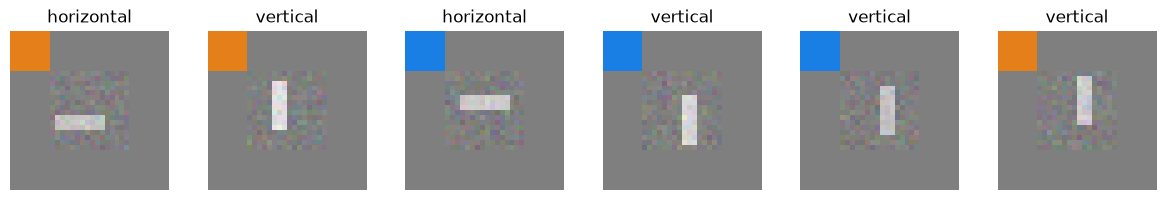

In [3]:
def make_split(n, agreement, seed):
    """Return a public (image, label) view and a separate benchmark-only oracle."""
    g = torch.Generator().manual_seed(seed)
    labels = torch.arange(n) % 2
    cue = labels.clone()
    for label in (0, 1):
        indices = (labels == label).nonzero().flatten()
        indices = indices[torch.randperm(len(indices), generator=g)]
        cue[indices[: round((1 - agreement) * len(indices))]] = 1 - label
    images = torch.full((n, 3, 32, 32), 0.5)
    images[:, :, 8:24, 8:24] += CENTRAL_NOISE * torch.randn(n, 3, 16, 16, generator=g)
    foreground = torch.zeros(n, 32, 32, dtype=torch.bool)
    for i, label in enumerate(labels.tolist()):
        cy, cx = (16 + torch.randint(-2, 3, (2,), generator=g)).tolist()
        h, w = (10, 3) if label == 0 else (3, 10)
        foreground[i, cy - h // 2 : cy - h // 2 + h, cx - w // 2 : cx - w // 2 + w] = True
        contrast = BAR_CONTRAST[0] + (BAR_CONTRAST[1] - BAR_CONTRAST[0]) * torch.rand((), generator=g)
        images[i, :, foreground[i]] += contrast
    colors = torch.tensor([[0.9, 0.5, 0.1], [0.1, 0.5, 0.9]])
    images[:, :, :8, :8] = colors[cue, :, None, None]
    order = torch.randperm(n, generator=g)
    public = {"images": images[order].clamp(0, 1), "labels": labels[order]}
    oracle = {"cue": cue[order], "foreground": foreground[order], "cue_box": (0, 0, 8), "agreement": agreement}
    return public, oracle


public_data, oracle_data = {}, {}
for regime in REGIMES:
    for seed in SEEDS:
        key = (regime, seed)
        public_data[key], oracle_data[key] = {}, {}
        for split, n, offset in (
            ("train", 1024, 0),
            ("discovery", 64, 1000),
            ("confirmation", 256, 2000),
            ("test", 1024, TEST_SEED_OFFSET),
        ):
            agreement = 0.95 if regime == "shortcut" and split == "train" else 0.5
            public_data[key][split], oracle_data[key][split] = make_split(n, agreement, seed + offset)


def tensor_hash(tensor):
    return hashlib.sha256(tensor.contiguous().numpy().tobytes()).hexdigest()


split_hashes = {
    f"{regime}/{seed}/{split}": tensor_hash(view["images"])
    for (regime, seed), splits in public_data.items()
    for split, view in splits.items()
}
test_hashes_before = {key: tensor_hash(splits["test"]["images"]) for key, splits in public_data.items()}
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
preview = public_data[("shortcut", SEEDS[0])]["discovery"]
for i, ax in enumerate(axes):
    ax.imshow(preview["images"][i].permute(1, 2, 0))
    ax.set_title(("vertical", "horizontal")[preview["labels"][i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

## Train the pilot and define two budget-matched continuations

The unchanged arm still receives all 32 continuation epochs. All arms start from identical pilot weights,
reset Adam state in the same way, use identical minibatches, and have the same number of examples and
optimizer steps. Ordinary augmentation is task-preserving **random border erasing**, a constrained version
of random erasing. Guided erasing changes only its location; successful selection adds no data.

The pilot is shared rather than charged only to the guided arm. CAM extraction, confirmation edits, and
bootstrap calculations are extra diagnostic compute, reported separately; the end-to-end costs are not equal.


In [4]:
class TinyClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.head = nn.Linear(16, 2)

    def forward(self, inputs):
        return self.head(self.features(inputs - INPUT_CENTER).mean((2, 3)))


def erase_tiles(images, locations, edited):
    output = images.clone()
    for i in edited.nonzero().flatten().tolist():
        y, x = TILES[int(locations[i])]
        output[i, :, y : y + 8, x : x + 8] = 0.5
    return output


def train_epochs(model, train, epochs, seed, arm="unchanged", chosen=None):
    g = torch.Generator().manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
    history = []
    for epoch in range(epochs):
        order = torch.randperm(len(train["labels"]), generator=g)
        locations = torch.randint(len(TILES), (len(order),), generator=g)
        edited = torch.rand(len(order), generator=g) < EDIT_PROBABILITY
        model.train()
        loss_sum = 0.0
        for start in range(0, len(order), BATCH):
            idx = order[start : start + BATCH]
            images = train["images"][idx]
            loc = locations[start : start + BATCH]
            if arm in ("guided", "gated") and chosen is not None:
                loc = torch.full_like(loc, chosen)
            if arm == "ordinary" or (arm in ("guided", "gated") and chosen is not None):
                images = erase_tiles(images, loc, edited[start : start + BATCH])
            optimizer.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(images), train["labels"][idx])
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(idx)
        history.append(loss_sum / len(order))
    model.eval()
    return history


def probabilities(model, images):
    with torch.no_grad():
        return torch.cat([model(batch).softmax(1) for batch in images.split(BATCH)])


def checkpoint_hash(model):
    packed = b"".join(t.contiguous().numpy().tobytes() for t in model.state_dict().values())
    return hashlib.sha256(packed).hexdigest()

## CAM proposal and a held-out intervention test

Explain **every fixed discovery image**, including correct predictions and mistakes, using its predicted raw
logit. Upsample GradCAM to the input frame. Rank the mean normalized CAM mass in each permissible tile;
brightness alone is not a causal claim. Save one example with the existing `explain().save()` API and preserve
all maps plus per-probe errors/blank flags in a separate archive.

For each shortlisted region, test (a) replacement by neutral gray and (b) a 50% blend with a label-independent
training donor's same region. Translate the **same additive pixel change** to each of the seven other tiles as
controls. The areas, per-image L1/L2 magnitudes, and number of forward calls match exactly. All edits preserve
the central bar. Controls can introduce a patch elsewhere; they test location specificity under this operator,
not realism. In this fixture the controls stay in [0,1] without clipping.

Record original-predicted-class probability drops, true-label probability drops, prediction flips, and edited
accuracy. A probability drop is sensitivity evidence, not calibrated confidence or causal identification.
Confirmation samples are separate from CAM discovery, and test images are never edited for diagnosis.


In [5]:
def cam_proposals(model, discovery, prefix):
    masses, rows, saved_maps = [], [], []
    for i, (image, label) in enumerate(zip(discovery["images"], discovery["labels"], strict=True)):
        row = {"sample": i, "expected": int(label)}
        array = np.full((8, 8), np.nan, dtype=np.float32)
        try:
            result = explain(
                model,
                image[None],
                expected_class_idx=int(label),
                class_names=("vertical", "horizontal"),
                target_layer="features",
            )
            cam = result.cams[result.predicted_class_idx][0]
            blank = bool(cam.max() == cam.min())
            row.update(
                status="blank" if blank else "ok",
                predicted=result.predicted_class_idx,
                correct=result.predicted_class_idx == int(label),
            )
            array = cam.numpy()
            if not blank:
                full = F.interpolate(cam[None, None], (32, 32), mode="bilinear", align_corners=False)[0, 0]
                mass = [float(full[y : y + 8, x : x + 8].sum() / full.sum()) for y, x in TILES]
                if not any("bundle" in r for r in rows):
                    from PIL import Image

                    model_view = Image.fromarray((image.permute(1, 2, 0).numpy() * 255).round().astype("uint8"))
                    bundle = result.save(artifact_dir / f"{prefix}-example", model_view)
                    model_view.save(bundle / "model-input.png")
                    np.save(bundle / "model-input.npy", image.numpy(), allow_pickle=False)
                    (bundle / "notebook-context.json").write_text(
                        json.dumps(
                            {
                                "source_revision": SOURCE_REVISION,
                                "pilot_hash": checkpoint_hash(model),
                                "sample": i,
                                "preprocessing": "32x32 RGB float input; centering inside model",
                                "display": "PNG is rounded to 8-bit; model-input.npy preserves the exact float tensor",
                            },
                            indent=2,
                        ),
                        encoding="utf-8",
                    )
                    row["bundle"] = bundle.name
                masses.append(mass)
        except Exception as error:  # Preserve individual extraction failures; do not treat them as negative evidence.
            row.update(status="error", error_type=type(error).__name__, error=str(error))
            array = np.full((8, 8), np.nan, dtype=np.float32)
        saved_maps.append(array)
        rows.append(row)
    np.savez_compressed(artifact_dir / f"{prefix}-cams.npz", maps=np.stack(saved_maps))
    if not masses:
        return [], rows, []
    scores = np.mean(masses, axis=0)
    ranking = np.argsort(-scores, kind="stable").tolist()
    return ranking[:3], rows, scores.tolist()


def intervention(images, tile, kind, donors):
    y, x = TILES[tile]
    patch = images[:, :, y : y + 8, x : x + 8]
    replacement = (
        torch.full_like(patch, 0.5) if kind == "neutralize" else (patch + donors[:, :, y : y + 8, x : x + 8]) / 2
    )
    delta = replacement - patch
    target = images.clone()
    target[:, :, y : y + 8, x : x + 8] += delta
    controls = []
    for control_tile, (cy, cx) in enumerate(TILES):
        if control_tile != tile:
            control = images.clone()
            control[:, :, cy : cy + 8, cx : cx + 8] += delta
            controls.append(control)
    assert 0 <= target.min() <= target.max() <= 1
    assert all(0 <= c.min() <= c.max() <= 1 for c in controls)
    target_energy = (target - images).flatten(1).square().sum(1)
    assert all(torch.allclose((c - images).flatten(1).square().sum(1), target_energy, atol=1e-6) for c in controls)
    return target, controls


def confirm_proposals(model, confirmation, train, shortlist, seed):
    images, labels = confirmation["images"], confirmation["labels"]
    original = probabilities(model, images)
    predictions = original.argmax(1)
    idx = torch.arange(len(images))
    g = torch.Generator().manual_seed(seed + 4000)
    donors = train["images"][torch.randint(len(train["labels"]), (len(images),), generator=g)]
    records = []
    for tile in shortlist:
        for kind in ("neutralize", "donor_blend"):
            target, controls = intervention(images, tile, kind, donors)
            edited = probabilities(model, target)
            control_probs = torch.stack([probabilities(model, control) for control in controls])
            target_drop = original[idx, predictions] - edited[idx, predictions]
            control_drop = original[idx, predictions] - control_probs[:, idx, predictions].mean(0)
            effect = (target_drop - control_drop).numpy()
            bootstrap = np.random.default_rng(seed + 5000).choice(effect, (1000, len(effect))).mean(1)
            lo, hi = np.quantile(bootstrap, [0.025, 0.975]).tolist()
            records.append({
                "tile": tile,
                "box_yx": list(TILES[tile]),
                "edit": kind,
                "predicted_probability_drop": float(target_drop.mean()),
                "control_probability_drop": float(control_drop.mean()),
                "paired_excess_drop": float(effect.mean()),
                "bootstrap_95": [lo, hi],
                "label_probability_drop": float((original[idx, labels] - edited[idx, labels]).mean()),
                "target_accuracy": float((edited.argmax(1) == labels).float().mean()),
                "original_accuracy": float((predictions == labels).float().mean()),
                "target_flip_rate": float((edited.argmax(1) != predictions).float().mean()),
                "control_flip_rate": float((control_probs.argmax(2) != predictions).float().mean()),
                "supported": float(effect.mean()) > 0.02 and lo > 0,
            })
    chosen = next((tile for tile in shortlist if all(r["supported"] for r in records if r["tile"] == tile)), None)
    return chosen, records

## Freeze all repairs before opening the final test

For each seed and regime, train a pilot, collect discovery evidence, verify its shortlist on confirmation data,
then continue all four arms. Selected locations and all rejected tests are stored. Guided erasing tests a
provisional CAM proposal when confirmation is inconclusive; gated erasing then remains unchanged.
No test predictions or oracle annotations enter this cell.


In [7]:
models, runs = {}, []
experiment_started = time.perf_counter()
for regime in REGIMES:
    for seed in SEEDS:
        key = (regime, seed)
        train = public_data[key]["train"]
        torch.manual_seed(seed)
        pilot = TinyClassifier()
        t0 = time.perf_counter()
        pilot_losses = train_epochs(pilot, train, PILOT_EPOCHS, seed)
        pilot_seconds = time.perf_counter() - t0
        pilot_state_hash = checkpoint_hash(pilot)
        t0 = time.perf_counter()
        shortlist, probes, cam_scores = cam_proposals(pilot, public_data[key]["discovery"], f"{regime}-{seed}")
        chosen, interventions = confirm_proposals(pilot, public_data[key]["confirmation"], train, shortlist, seed)
        diagnosis_seconds = time.perf_counter() - t0
        diagnosis = {
            "status": "supported_location_sensitivity" if chosen is not None else "unresolved",
            "chosen_tile": chosen,
            "cam_scores": cam_scores,
            "shortlist": shortlist,
            "guided_tile": chosen if chosen is not None else (shortlist[0] if shortlist else None),
            "guided_selection": "supported" if chosen is not None else "provisional",
            "probes": probes,
            "interventions": interventions,
        }
        for arm in ARMS:
            model = copy.deepcopy(pilot)
            assert checkpoint_hash(model) == pilot_state_hash
            t0 = time.perf_counter()
            location = diagnosis["guided_tile"] if arm == "guided" else chosen
            losses = train_epochs(model, train, REPAIR_EPOCHS, seed + 6000, arm, location)
            seconds = time.perf_counter() - t0
            models[(regime, seed, arm)] = model
            checkpoint_file = f"{regime}-{seed}-{arm}.pt"
            torch.save(model.state_dict(), artifact_dir / checkpoint_file)
            runs.append({
                "regime": regime,
                "seed": seed,
                "arm": arm,
                "diagnosis": diagnosis,
                "pilot_hash": pilot_state_hash,
                "final_hash": checkpoint_hash(model),
                "checkpoint": checkpoint_file,
                "pilot_losses": pilot_losses,
                "losses": losses,
                "pilot_seconds_shared": pilot_seconds,
                "diagnostic_seconds_shared": diagnosis_seconds,
                "continuation_seconds": seconds,
                "optimizer_steps": (PILOT_EPOCHS + REPAIR_EPOCHS) * 16,
                "training_presentations": (PILOT_EPOCHS + REPAIR_EPOCHS) * 1024,
            })
        print(
            f"{regime}, seed {seed}: {diagnosis['status']}, gated={chosen}, "
            f"guided={diagnosis['guided_tile']}; all continuations frozen.",
            flush=True,
        )
training_seconds = time.perf_counter() - experiment_started

shortcut, seed 7: unresolved, gated=None, guided=0; all continuations frozen.


shortcut, seed 17: unresolved, gated=None, guided=0; all continuations frozen.


shortcut, seed 27: unresolved, gated=None, guided=0; all continuations frozen.


no_shortcut, seed 7: unresolved, gated=None, guided=0; all continuations frozen.


no_shortcut, seed 17: unresolved, gated=None, guided=6; all continuations frozen.


no_shortcut, seed 27: unresolved, gated=None, guided=6; all continuations frozen.


In [8]:
diagnostic_rows = []
for run in runs:
    if run["arm"] != "unchanged":
        continue
    d = run["diagnosis"]
    statuses = {s: sum(p["status"] == s for p in d["probes"]) for s in ("ok", "blank", "error")}
    print(
        run["regime"],
        run["seed"],
        "probe statuses:",
        statuses,
        "successes:",
        sum(p.get("correct", False) for p in d["probes"]),
        "chosen:",
        d["chosen_tile"],
    )
    for r in d["interventions"]:
        diagnostic_rows.append(
            f"| {run['regime']} | {run['seed']} | {r['tile']} | {r['edit']} | "
            f"{r['paired_excess_drop']:.3f} | [{r['bootstrap_95'][0]:.3f}, {r['bootstrap_95'][1]:.3f}] | "
            f"{r['supported']} |"
        )
display(
    Markdown(
        "| Regime | Seed | Tile | Edit | Excess drop | Descriptive 95% interval | Supported |\n"
        "|---|---:|---:|---|---:|---|---|\n" + "\n".join(diagnostic_rows)
    )
)

shortcut 7 probe statuses: {'ok': 64, 'blank': 0, 'error': 0} successes: 32 chosen: None
shortcut 17 probe statuses: {'ok': 64, 'blank': 0, 'error': 0} successes: 32 chosen: None
shortcut 27 probe statuses: {'ok': 64, 'blank': 0, 'error': 0} successes: 32 chosen: None
no_shortcut 7 probe statuses: {'ok': 64, 'blank': 0, 'error': 0} successes: 64 chosen: None
no_shortcut 17 probe statuses: {'ok': 64, 'blank': 0, 'error': 0} successes: 56 chosen: None
no_shortcut 27 probe statuses: {'ok': 64, 'blank': 0, 'error': 0} successes: 64 chosen: None


| Regime | Seed | Tile | Edit | Excess drop | Descriptive 95% interval | Supported |
|---|---:|---:|---|---:|---|---|
| shortcut | 7 | 0 | neutralize | 0.059 | [-0.004, 0.123] | False |
| shortcut | 7 | 0 | donor_blend | 0.030 | [-0.017, 0.077] | False |
| shortcut | 7 | 1 | neutralize | 0.000 | [-0.000, 0.000] | False |
| shortcut | 7 | 1 | donor_blend | 0.000 | [-0.000, 0.000] | False |
| shortcut | 7 | 7 | neutralize | 0.000 | [-0.000, 0.000] | False |
| shortcut | 7 | 7 | donor_blend | 0.000 | [-0.000, 0.000] | False |
| shortcut | 17 | 0 | neutralize | 0.062 | [-0.010, 0.136] | False |
| shortcut | 17 | 0 | donor_blend | 0.032 | [-0.022, 0.087] | False |
| shortcut | 17 | 1 | neutralize | -0.000 | [-0.000, 0.000] | False |
| shortcut | 17 | 1 | donor_blend | -0.000 | [-0.000, 0.000] | False |
| shortcut | 17 | 7 | neutralize | -0.000 | [-0.000, 0.000] | False |
| shortcut | 17 | 7 | donor_blend | -0.000 | [-0.000, 0.000] | False |
| shortcut | 27 | 0 | neutralize | 0.016 | [-0.076, 0.114] | False |
| shortcut | 27 | 0 | donor_blend | 0.011 | [-0.062, 0.075] | False |
| shortcut | 27 | 1 | neutralize | 0.000 | [-0.000, 0.000] | False |
| shortcut | 27 | 1 | donor_blend | 0.000 | [-0.000, 0.000] | False |
| shortcut | 27 | 7 | neutralize | 0.000 | [-0.000, 0.000] | False |
| shortcut | 27 | 7 | donor_blend | 0.000 | [-0.000, 0.000] | False |
| no_shortcut | 7 | 0 | neutralize | -0.023 | [-0.041, -0.004] | False |
| no_shortcut | 7 | 0 | donor_blend | -0.016 | [-0.030, -0.001] | False |
| no_shortcut | 7 | 6 | neutralize | -0.000 | [-0.000, 0.000] | False |
| no_shortcut | 7 | 6 | donor_blend | -0.000 | [-0.000, 0.000] | False |
| no_shortcut | 7 | 5 | neutralize | -0.000 | [-0.000, 0.000] | False |
| no_shortcut | 7 | 5 | donor_blend | -0.000 | [-0.000, 0.000] | False |
| no_shortcut | 17 | 6 | neutralize | 0.000 | [-0.000, 0.000] | False |
| no_shortcut | 17 | 6 | donor_blend | 0.000 | [-0.000, 0.000] | False |
| no_shortcut | 17 | 5 | neutralize | 0.000 | [-0.000, 0.000] | False |
| no_shortcut | 17 | 5 | donor_blend | 0.000 | [-0.000, 0.000] | False |
| no_shortcut | 17 | 7 | neutralize | 0.000 | [-0.000, 0.000] | False |
| no_shortcut | 17 | 7 | donor_blend | 0.000 | [-0.000, 0.000] | False |
| no_shortcut | 27 | 6 | neutralize | -0.000 | [-0.000, 0.000] | False |
| no_shortcut | 27 | 6 | donor_blend | -0.000 | [-0.000, 0.000] | False |
| no_shortcut | 27 | 5 | neutralize | -0.000 | [-0.000, 0.000] | False |
| no_shortcut | 27 | 5 | donor_blend | -0.000 | [-0.000, 0.000] | False |
| no_shortcut | 27 | 7 | neutralize | -0.000 | [-0.000, 0.000] | False |
| no_shortcut | 27 | 7 | donor_blend | -0.000 | [-0.000, 0.000] | False |

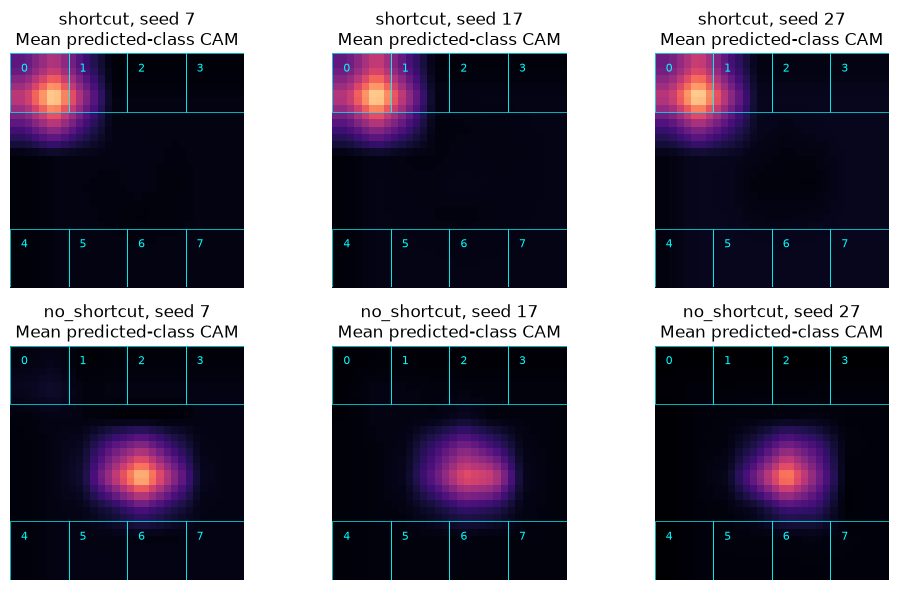

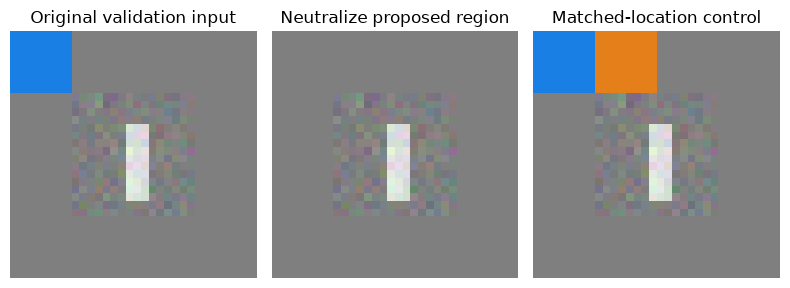

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax, run in zip(axes.flat, [r for r in runs if r["arm"] == "unchanged"], strict=True):
    maps = np.load(artifact_dir / f"{run['regime']}-{run['seed']}-cams.npz", allow_pickle=False)["maps"]
    valid = maps[np.isfinite(maps).all((1, 2))]
    if len(valid):
        mean_map = torch.from_numpy(valid.mean(0))
        full = F.interpolate(mean_map[None, None], (32, 32), mode="bilinear", align_corners=False)[0, 0]
        ax.imshow(full, vmin=0, vmax=1, cmap="magma")
        for tile, (y, x) in enumerate(TILES):
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 8, 8, fill=False, edgecolor="cyan", linewidth=0.5))
            ax.text(x + 1, y + 2, str(tile), color="cyan", fontsize=8)
    else:
        ax.text(0.1, 0.5, "No finite CAMs; unresolved")
    ax.set_title(f"{run['regime']}, seed {run['seed']}\nMean predicted-class CAM")
    ax.axis("off")
plt.tight_layout()
plt.show()

first = runs[0]
tile = first["diagnosis"]["guided_tile"]
if tile is not None:
    key = (first["regime"], first["seed"])
    original = public_data[key]["confirmation"]["images"][:1]
    target, controls = intervention(original, tile, "neutralize", public_data[key]["train"]["images"][:1])
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    for ax, image, title in zip(
        axes,
        (original[0], target[0], controls[0][0]),
        ("Original validation input", "Neutralize proposed region", "Matched-location control"),
        strict=True,
    ):
        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Final untouched test results: every seed and every group

Only now open the oracle color IDs to compute the four label × cue group accuracies. Worst-group accuracy
is the minimum group accuracy **within each run**, then summarized across seeds. Report sample standard
deviation across the three runs and paired differences; these are descriptive, not a claim of statistical
superiority. Keep every continuation even if guided training performs worse or diagnosis is unresolved.


In [10]:
for run in runs:
    key = (run["regime"], run["seed"])
    test = public_data[key]["test"]
    prediction = probabilities(models[(*key, run["arm"])], test["images"]).argmax(1)
    cue = oracle_data[key]["test"]["cue"]  # Benchmark-only; not passed to any selector or trainer.
    correct = prediction == test["labels"]
    groups = []
    for label in (0, 1):
        for color in (0, 1):
            mask = (test["labels"] == label) & (cue == color)
            groups.append({
                "label": label,
                "cue": color,
                "n": int(mask.sum()),
                "correct": int(correct[mask].sum()),
                "accuracy": float(correct[mask].float().mean()),
            })
    run["test"] = {
        "n": len(correct),
        "accuracy": float(correct.float().mean()),
        "worst_group": min(g["accuracy"] for g in groups),
        "groups": groups,
        "predictions": prediction.tolist(),
    }


def mean_sd(values):
    return float(np.mean(values)), float(np.std(values, ddof=1))


per_seed_rows, summary_rows, summaries = [], [], []
for run in runs:
    scores = run["test"]
    group_scores = ", ".join(
        f"{g['label']}/{g['cue']}: {100 * g['accuracy']:.1f}% (n={g['n']})" for g in scores["groups"]
    )
    per_seed_rows.append(
        f"| {run['regime']} | {run['seed']} | {run['arm']} | {100 * scores['accuracy']:.2f} | "
        f"{100 * scores['worst_group']:.2f} | {group_scores} |"
    )
for regime in REGIMES:
    for arm in ARMS:
        selected = [r for r in runs if r["regime"] == regime and r["arm"] == arm]
        avg, avg_sd = mean_sd([r["test"]["accuracy"] for r in selected])
        worst, worst_sd = mean_sd([r["test"]["worst_group"] for r in selected])
        summaries.append({
            "regime": regime,
            "arm": arm,
            "accuracy_mean": avg,
            "accuracy_sd": avg_sd,
            "worst_group_mean": worst,
            "worst_group_sd": worst_sd,
        })
        summary_rows.append(
            f"| {regime} | {arm} | {100 * avg:.2f} ± {100 * avg_sd:.2f} | {100 * worst:.2f} ± {100 * worst_sd:.2f} |"
        )
display(
    Markdown(
        "| Regime | Seed | Arm | Accuracy % | Worst group % | Label/cue groups |\n"
        "|---|---:|---|---:|---:|---|\n" + "\n".join(per_seed_rows)
    )
)
display(
    Markdown(
        "| Regime | Arm | Mean accuracy % ± SD | Mean worst-group % ± SD |\n"
        "|---|---|---:|---:|\n" + "\n".join(summary_rows)
    )
)

paired_differences = []
for regime in REGIMES:
    for reference in ("unchanged", "ordinary"):
        diffs = []
        for seed in SEEDS:
            guided = next(r for r in runs if (r["regime"], r["seed"], r["arm"]) == (regime, seed, "guided"))
            other = next(r for r in runs if (r["regime"], r["seed"], r["arm"]) == (regime, seed, reference))
            diffs.append({
                "seed": seed,
                **{metric: guided["test"][metric] - other["test"][metric] for metric in ("accuracy", "worst_group")},
            })
        paired_differences.append({"regime": regime, "comparison": f"guided - {reference}", "per_seed": diffs})
print(json.dumps(paired_differences, indent=2))

| Regime | Seed | Arm | Accuracy % | Worst group % | Label/cue groups |
|---|---:|---|---:|---:|---|
| shortcut | 7 | unchanged | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 7 | ordinary | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 7 | guided | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 7 | gated | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 17 | unchanged | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 17 | ordinary | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 17 | guided | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 17 | gated | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 27 | unchanged | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 27 | ordinary | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 27 | guided | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| shortcut | 27 | gated | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 7 | unchanged | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 7 | ordinary | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 7 | guided | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 7 | gated | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 17 | unchanged | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 17 | ordinary | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 17 | guided | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 17 | gated | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 27 | unchanged | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 27 | ordinary | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 27 | guided | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |
| no_shortcut | 27 | gated | 100.00 | 100.00 | 0/0: 100.0% (n=256), 0/1: 100.0% (n=256), 1/0: 100.0% (n=256), 1/1: 100.0% (n=256) |

| Regime | Arm | Mean accuracy % ± SD | Mean worst-group % ± SD |
|---|---|---:|---:|
| shortcut | unchanged | 100.00 ± 0.00 | 100.00 ± 0.00 |
| shortcut | ordinary | 100.00 ± 0.00 | 100.00 ± 0.00 |
| shortcut | guided | 100.00 ± 0.00 | 100.00 ± 0.00 |
| shortcut | gated | 100.00 ± 0.00 | 100.00 ± 0.00 |
| no_shortcut | unchanged | 100.00 ± 0.00 | 100.00 ± 0.00 |
| no_shortcut | ordinary | 100.00 ± 0.00 | 100.00 ± 0.00 |
| no_shortcut | guided | 100.00 ± 0.00 | 100.00 ± 0.00 |
| no_shortcut | gated | 100.00 ± 0.00 | 100.00 ± 0.00 |

[
  {
    "regime": "shortcut",
    "comparison": "guided - unchanged",
    "per_seed": [
      {
        "seed": 7,
        "accuracy": 0.0,
        "worst_group": 0.0
      },
      {
        "seed": 17,
        "accuracy": 0.0,
        "worst_group": 0.0
      },
      {
        "seed": 27,
        "accuracy": 0.0,
        "worst_group": 0.0
      }
    ]
  },
  {
    "regime": "shortcut",
    "comparison": "guided - ordinary",
    "per_seed": [
      {
        "seed": 7,
        "accuracy": 0.0,
        "worst_group": 0.0
      },
      {
        "seed": 17,
        "accuracy": 0.0,
        "worst_group": 0.0
      },
      {
        "seed": 27,
        "accuracy": 0.0,
        "worst_group": 0.0
      }
    ]
  },
  {
    "regime": "no_shortcut",
    "comparison": "guided - unchanged",
    "per_seed": [
      {
        "seed": 7,
        "accuracy": 0.0,
        "worst_group": 0.0
      },
      {
        "seed": 17,
        "accuracy": 0.0,
        "worst_group": 0.0
      },
   

## Interpretation and limits

**Committed CPU measurement:** all four arms reached 100% average and 100% worst-group accuracy,
with 0 percentage-point SD across the three seeds, in both regimes. Every guided-minus-ordinary and
guided-minus-unchanged difference was zero. The shortcut pilots were at 50% confirmation accuracy and
CAM ranked the injected corner first in all three seeds, but all location-specific confirmation gates stayed
unresolved. Unchanged continuation learned the task too. This is a **null repair advantage**, with a ceiling
at the final checkpoint, not evidence that CAM improves training or that erasing is necessary.

The tables above distinguish successful location-sensitivity tests from successful training repair. A positive
intervention test cannot guarantee that erasing will remove a learned dependency. The ordinary augmentation
arm is essential: guided repair adds value here only if its **untouched test** comparison supports that claim.
Three seeds and a synthetic task cannot establish a general method ranking or deployment benefit. A null,
negative, or inconsistent guided-minus-ordinary difference must remain a null or unresolved result.

Even a positive guided-versus-ordinary result would establish a difference between these complete workflows,
not the incremental value of CAM itself. A non-CAM targeted selector is not trained here, so no unique CAM
advantage is claimed. Gated training shows the cost of withholding a provisional intervention; it is not a
fourth independent diagnosis.

The no-shortcut control assesses false positive diagnosis and unnecessary intervention costs. It removes the
injected **correlation**, not the colored patch or every possible model shortcut. A spatial sensitivity finding
there is not automatically proof of a shortcut. The CAM shortlist can miss a dependency; all positive evidence
is specific to the chosen layer, probes, edit operators, task contract, and supplied validation distribution.
The group minimum has sampling variability even with 256 test examples per group. Bootstrap intervals in
diagnosis concern images, while final SD concerns training seeds. Neither is a population confidence interval.

Review the rejected proposal rows and all no-shortcut results. There is no automatic promotion of a repair,
and test results do not feed back into selection. The saved JSON includes the full protocol, seed-level losses,
timings, diagnoses, per-group counts, test predictions, immutable data hashes, and checkpoint identifiers.


## Acceptance checks and durable run record

These checks verify split separation, label preservation, equal edit energy/area, train-only donors,
equal update budgets, shared initialization, test immutability, complete results, and unresolved-diagnosis
fallback. They never require favorable accuracy, a supported diagnosis, or a nonblank CAM. Separate fault
probes check error and blank-map retention, without changing the experiment selection.
The new temporary directory prevents overwriting earlier runs. Copy/download it before the runtime ends.


In [11]:
assert len(runs) == len(REGIMES) * len(SEEDS) * len(ARMS)
for key, splits in public_data.items():
    assert len({tensor_hash(view["images"]) for view in splits.values()}) == len(splits)
    # Check individual image hashes, not only hashes of whole splits.
    image_ids = [tensor_hash(image) for view in splits.values() for image in view["images"]]
    assert len(image_ids) == len(set(image_ids))
    assert tensor_hash(splits["test"]["images"]) == test_hashes_before[key]
    assert test_hashes_before[key] != INITIAL_ATTEMPT["split_hashes"][f"{key[0]}/{key[1]}/test"]
    for split in ("discovery", "confirmation", "test"):
        label, cue = splits[split]["labels"], oracle_data[key][split]["cue"]
        assert all(int(((label == y) & (cue == c)).sum()) == len(label) // 4 for y in (0, 1) for c in (0, 1))
    view = splits["confirmation"]
    donors = splits["train"]["images"][: len(view["images"])]
    foreground = oracle_data[key]["confirmation"]["foreground"]
    for tile in range(len(TILES)):
        for kind in ("neutralize", "donor_blend"):
            target, controls = intervention(view["images"], tile, kind, donors)
            for edited in [target, *controls]:
                changed = (edited != view["images"]).any(1)
                assert not (changed & foreground).any()
                assert torch.equal(edited[:, :, 8:24, 8:24], view["images"][:, :, 8:24, 8:24])
                assert (changed.sum((1, 2)) <= 64).all()
                assert torch.allclose(
                    (edited - view["images"]).abs().flatten(1).sum(1),
                    (target - view["images"]).abs().flatten(1).sum(1),
                    atol=1e-5,
                )
    arms = [r for r in runs if (r["regime"], r["seed"]) == key]
    assert len({r["pilot_hash"] for r in arms}) == 1
    assert {r["optimizer_steps"] for r in arms} == {576}
    assert {r["training_presentations"] for r in arms} == {36864}
    for run in arms:
        assert len(run["diagnosis"]["probes"]) == 64
        assert len(run["test"]["predictions"]) == 1024
        assert all(g["n"] == 256 and 0 <= g["correct"] <= g["n"] for g in run["test"]["groups"])
        assert math.isfinite(run["test"]["accuracy"]) and math.isfinite(run["test"]["worst_group"])
        assert len(run["losses"]) == REPAIR_EPOCHS and all(math.isfinite(v) for v in run["losses"])
        saved_state = torch.load(artifact_dir / run["checkpoint"], weights_only=True)
        assert all(
            torch.equal(saved_state[name], value) for name, value in models[(*key, run["arm"])].state_dict().items()
        )
        effective_tile = run["diagnosis"]["guided_tile"] if run["arm"] == "guided" else run["diagnosis"]["chosen_tile"]
        if run["arm"] in ("guided", "gated") and effective_tile is None:
            unchanged = next(r for r in arms if r["arm"] == "unchanged")
            assert run["final_hash"] == unchanged["final_hash"]
    diagnosis = arms[0]["diagnosis"]
    archive = np.load(artifact_dir / f"{key[0]}-{key[1]}-cams.npz", allow_pickle=False)
    assert archive["maps"].shape == (64, 8, 8)
    for probe, cam in zip(diagnosis["probes"], archive["maps"], strict=True):
        if probe["status"] == "error":
            assert np.isnan(cam).all()
        else:
            assert np.isfinite(cam).all()
            assert bool(cam.max() == cam.min()) == (probe["status"] == "blank")
        if "bundle" in probe:
            bundle = artifact_dir / probe["bundle"]
            saved_input = np.load(bundle / "model-input.npy", allow_pickle=False)
            np.testing.assert_array_equal(saved_input, splits["discovery"]["images"][probe["sample"]].numpy())
    erased = erase_tiles(view["images"][:8], torch.arange(8), torch.ones(8, dtype=torch.bool))
    assert torch.equal(erased[:, :, 8:24, 8:24], view["images"][:8, :, 8:24, 8:24])


class BlankClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Conv2d(3, 2, 1, bias=False)
        nn.init.zeros_(self.features.weight)

    def forward(self, inputs):
        return self.features(inputs).mean((2, 3))


class DisconnectedClassifier(BlankClassifier):
    def forward(self, inputs):
        return inputs[:, :2].mean((2, 3))  # Valid logits, selected layer is never run.


fault_view = {"images": torch.zeros(2, 3, 32, 32), "labels": torch.tensor([0, 1])}
blank_shortlist, blank_rows, _ = cam_proposals(BlankClassifier().eval(), fault_view, "blank-check")
error_shortlist, error_rows, _ = cam_proposals(DisconnectedClassifier().eval(), fault_view, "error-check")
assert not blank_shortlist and all(r["status"] == "blank" for r in blank_rows)
assert not error_shortlist and all(r["status"] == "error" for r in error_rows)
print(
    "PASS: complete records, split isolation, label-preserving matched edits, equal training budgets, untouched test, and fault retention."
)

PASS: complete records, split isolation, label-preserving matched edits, equal training budgets, untouched test, and fault retention.


In [12]:
protocol = {
    "notebook_base": "frgfm/notebooks@493d93b0be06eee98264609e6c025dc798e65ad2",
    "seeds": list(SEEDS),
    "regimes": list(REGIMES),
    "arms": list(ARMS),
    "splits": {"train": 1024, "discovery": 64, "confirmation": 256, "test": 1024},
    "pilot_epochs": PILOT_EPOCHS,
    "continuation_epochs": REPAIR_EPOCHS,
    "batch_size": BATCH,
    "central_noise_sd": CENTRAL_NOISE,
    "bar_contrast_range": BAR_CONTRAST,
    "input_centering": INPUT_CENTER,
    "split_seed_offsets": {"train": 0, "discovery": 1000, "confirmation": 2000, "test": TEST_SEED_OFFSET},
    "optimizer": "Adam(lr=0.003), reset at continuation for all arms",
    "tiles_yx": TILES,
    "target_layer": "features",
    "cam": "GradCAM; original predicted raw logit; 8x8 -> 32x32 bilinear",
    "selection": "top-3 CAM rank; both edits excess drop > 0.02 and paired bootstrap lower bound > 0",
    "guided_policy": "first supported tile, else top provisional CAM tile; no usable maps => unchanged",
    "gated_policy": "first supported tile, else unchanged",
    "bootstrap": "1000 image resamples; seed + 5000; descriptive, no multiplicity correction",
    "edit_probability": EDIT_PROBABILITY,
    "repair": "8x8 border erasure, neutral 0.5",
    "available_to_workflow": ["train/discovery/confirmation images", "class labels", "protected central task region"],
    "oracle_usage": "generator, acceptance checks, and final group scoring only",
    "test_policy": "one evaluation after all training frozen; no feedback into selection",
    "augmentation_pairing": "seed + 6000; same batch permutation and Bernoulli decisions each epoch",
    "donor_source": "training only; seed + 4000, sampled without label conditioning",
    "diagnostic_compute_extra": "64 explanations (predicted + expected), 48 edited confirmation passes of 256 images per resolved shortlist",
}
report = {
    "schema_version": 1,
    "protocol": protocol,
    "runtime": runtime,
    "split_hashes": split_hashes,
    "training_and_diagnosis_seconds": training_seconds,
    "runs": runs,
    "summary": summaries,
    "paired_differences": paired_differences,
    "initial_attempt": INITIAL_ATTEMPT,
    "fault_checks": {"blank": blank_rows, "error": error_rows},
}
report_path = artifact_dir / "experiment.json"
report_path.write_text(json.dumps(report, indent=2, allow_nan=False) + "\n", encoding="utf-8")
assert json.loads(report_path.read_text(encoding="utf-8"))["summary"] == summaries
print(f"Saved checkpoints, CAM arrays/example bundles, and complete JSON report: {artifact_dir}")
print(f"Training + diagnosis: {training_seconds:.1f} seconds; all 24 runs retained, including null/negative results.")

Saved checkpoints, CAM arrays/example bundles, and complete JSON report: /tmp/torchcam-shortcut-qnysa4ii
Training + diagnosis: 87.1 seconds; all 24 runs retained, including null/negative results.
